In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd

perGame = pd.read_csv('gdrive/My Drive/24-25PGStats.csv')
advStats = pd.read_csv('gdrive/My Drive/24-25AdvStats.csv')

# Merge on player name
totStats = pd.merge(perGame, advStats, on='Player')
totStats = totStats[totStats['Player'].notna()]
totStats = totStats[totStats['Player'] != ' ']
totStats.set_index('Player', inplace=True)

print(totStats.shape)
totStats.head()

(345, 17)


,Pos_x,G_x,MP,FGA,3PA,3P%,Pos_y,G_y,3PAr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%
Player,,,,,,,,,,,,,,,,,
Shai Gilgeous-Alexander,PG,76.0,34.2,21.8,5.7,0.375,PG,76.0,0.263,2.8,12.6,7.8,31.3,2.4,3.0,8.6,34.8
Giannis Antetokounmpo,PF,67.0,34.2,19.7,0.9,0.222,PF,67.0,0.048,7.3,29.7,19.0,36.0,1.2,3.2,11.2,35.2
Nikola Jokić,C,70.0,36.7,19.5,4.7,0.417,C,70.0,0.243,9.0,28.2,19.1,44.1,2.4,1.6,12.8,29.5
Luka Dončić,PG,50.0,35.4,20.5,9.6,0.368,PG,50.0,0.469,2.6,22.6,12.8,36.1,2.5,1.1,13.0,33.9
Anthony Edwards,SG,79.0,36.3,20.4,10.3,0.395,SG,79.0,0.503,2.4,14.8,8.7,20.9,1.6,1.7,12.0,31.4


In [ ]:
# Keep only players who actually played 20 games/15MPG
cleanStats = totStats[(totStats['MP'] >= 15) & (totStats['G_x'] >= 20)].copy()
cleanStats.drop(columns=['Pos_y', 'G_y'], inplace=True)

print(f"Players remaining: {len(cleanStats)}")
print(cleanStats['Pos_x'].value_counts())

Players remaining: 323
Pos_x
SG    91
PF    62
PG    58
C     56
SF    56
Name: count, dtype: int64


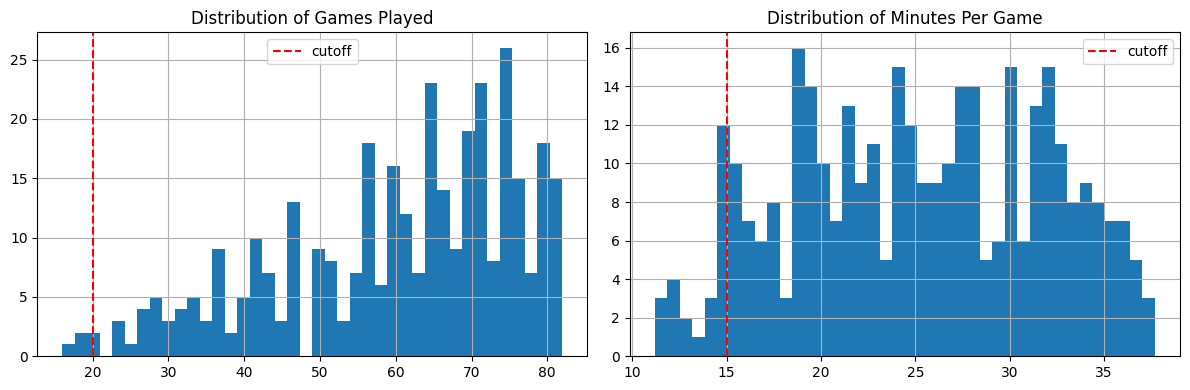

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

totStats['G_x'].hist(bins=40, ax=axes[0])
axes[0].set_title('Distribution of Games Played')
axes[0].axvline(20, color='red', linestyle='--', label='cutoff')
axes[0].legend()

totStats['MP'].hist(bins=40, ax=axes[1])
axes[1].set_title('Distribution of Minutes Per Game')
axes[1].axvline(15, color='red', linestyle='--', label='cutoff')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features: drop the position column, keep numeric stats
feature_cols = ['G_x', 'MP', 'FGA', '3PA', '3P%', '3PAr',
                'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%']

X = cleanStats[feature_cols].fillna(0)  # fill any missing with 0
y = cleanStats['Pos_x']                 # position is our target label

# Scale features to have mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 258
Test samples:     65


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Try different values of k
k_values = [1, 3, 5, 7, 9, 11]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    knn_accuracies.append(acc)
    print(f"k={k:2d}  accuracy={acc:.3f}")

best_k = k_values[knn_accuracies.index(max(knn_accuracies))]
print(f"\nBest k: {best_k} with accuracy {max(knn_accuracies):.3f}")

k= 1  accuracy=0.462
k= 3  accuracy=0.585
k= 5  accuracy=0.631
k= 7  accuracy=0.523
k= 9  accuracy=0.569
k=11  accuracy=0.600

Best k: 5 with accuracy 0.631


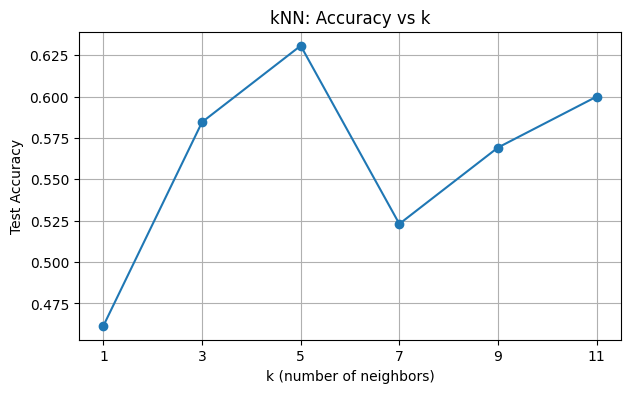

In [ ]:
# Plot accuracy vs k
plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('kNN: Accuracy vs k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

=== kNN (k=5) Classification Report ===
              precision    recall  f1-score   support

           C       0.79      1.00      0.88        11
          PF       0.33      0.15      0.21        13
          PG       0.82      0.75      0.78        12
          SF       0.43      0.55      0.48        11
          SG       0.65      0.72      0.68        18

    accuracy                           0.63        65
   macro avg       0.60      0.63      0.61        65
weighted avg       0.60      0.63      0.61        65



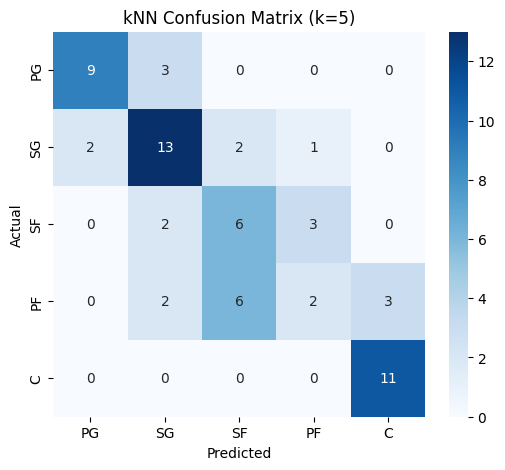

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Detailed report with the best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
knn_preds = best_knn.predict(X_test)

print(f"=== kNN (k={best_k}) Classification Report ===")
print(classification_report(y_test, knn_preds))

# Confusion matrix - rows=actual, columns=predicted
cm = confusion_matrix(y_test, knn_preds, labels=['PG','SG','SF','PF','C'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['PG','SG','SF','PF','C'],
            yticklabels=['PG','SG','SF','PF','C'], cmap='Blues')
plt.title(f'kNN Confusion Matrix (k={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from sklearn.svm import SVC

# Linear SVM — draws straight hyperplanes between classes
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
linear_preds = svm_linear.predict(X_test)
print("=== SVM (linear kernel) ===")
print(classification_report(y_test, linear_preds))

# RBF SVM — can draw curved boundaries, often works better in practice
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
rbf_preds = svm_rbf.predict(X_test)
print("=== SVM (RBF kernel) ===")
print(classification_report(y_test, rbf_preds))

=== SVM (linear kernel) ===
              precision    recall  f1-score   support

           C       0.92      1.00      0.96        11
          PF       0.50      0.31      0.38        13
          PG       0.82      0.75      0.78        12
          SF       0.23      0.27      0.25        11
          SG       0.62      0.72      0.67        18

    accuracy                           0.62        65
   macro avg       0.62      0.61      0.61        65
weighted avg       0.62      0.62      0.61        65

=== SVM (RBF kernel) ===
              precision    recall  f1-score   support

           C       0.85      1.00      0.92        11
          PF       0.40      0.15      0.22        13
          PG       0.73      0.67      0.70        12
          SF       0.33      0.27      0.30        11
          SG       0.56      0.83      0.67        18

    accuracy                           0.60        65
   macro avg       0.57      0.59      0.56        65
weighted avg       0.57 

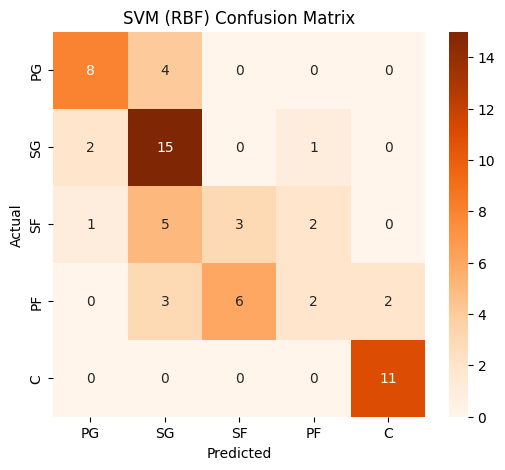

In [ ]:
# Confusion matrix for RBF SVM
cm_svm = confusion_matrix(y_test, rbf_preds, labels=['PG','SG','SF','PF','C'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', xticklabels=['PG','SG','SF','PF','C'],
            yticklabels=['PG','SG','SF','PF','C'], cmap='Oranges')
plt.title('SVM (RBF) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Model Comparison:
  kNN (k=5)             0.631
  SVM (linear)          0.615
  SVM (RBF)             0.600


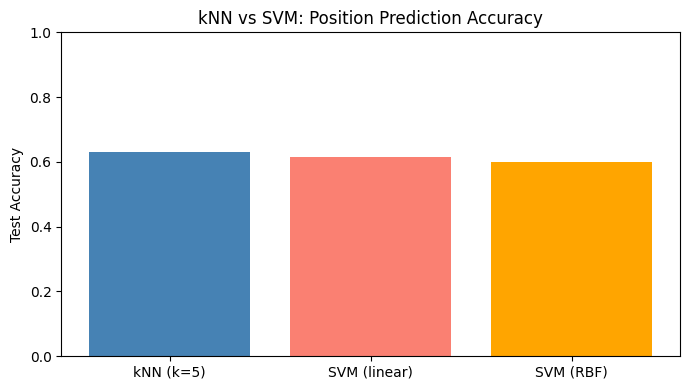

In [ ]:
results = {
    f'kNN (k={best_k})':        accuracy_score(y_test, knn_preds),
    'SVM (linear)':             accuracy_score(y_test, linear_preds),
    'SVM (RBF)':                accuracy_score(y_test, rbf_preds),
}

print("Model Comparison:")
for name, acc in results.items():
    print(f"  {name:20s}  {acc:.3f}")

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'salmon', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('kNN vs SVM: Position Prediction Accuracy')
plt.tight_layout()
plt.show()